# 10 Unsupervised PC Regression

1. Apply same variance filter as NB07 (top 20K genes) — apples-to-apples comparison
2. For each CV fold, fit PCA on **training data only** → extract top 800 PCs
3. Within the fold, AUC-select the top 100 PCs (train only)
4. Train RF on selected PCs → predict on test fold

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache, build_confounder_matrix, variance_filter
from gtex_biomarkers.labels import discover_tissue_category_pairs, assign_donor_labels
from gtex_biomarkers.models import make_rf_model, make_lr_pipeline, _auc_feature_selection, _impute_train_fold
from gtex_biomarkers.evaluation import plot_paired_auc_bar, plot_delta_bar

Config.ensure_dirs()

# Load data
X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()
rf_summary = pd.read_csv(Config.TABLES_DIR / 'cv_results_all_tissue_rf.csv')
three_way = pd.read_csv(Config.TABLES_DIR / 'cv_three_way_comparison.csv')

# Variance filter — same top 20K genes as NB07 (apples-to-apples)
X_wb_var, gene_var = variance_filter(X_wb)
print(f'Variance filter: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes')

# Build clinical co-variate matrix (same as NB09)
X_conf = build_confounder_matrix(df_age, blood_subjid)

print(f'Expression matrix: {X_wb_var.shape[0]} samples x {X_wb_var.shape[1]:,} genes')
print(f'Clinical co-variate matrix: {X_conf.shape[0]} samples x {X_conf.shape[1]} features ({list(X_conf.columns)})')

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


Variance filter: 59,033 → 20,000 genes
Expression matrix: 803 samples x 20,000 genes
Clinical co-variate matrix: 803 samples x 5 features (['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD'])


## 10.1 — Global PCA Sanity Check

How much variance do the top 800 PCs capture from the 20K variance-filtered genes?

Top 800 PCs explain 100.0% of total variance
Top 100 PCs explain 84.3%
Top 10 PCs explain 62.7%


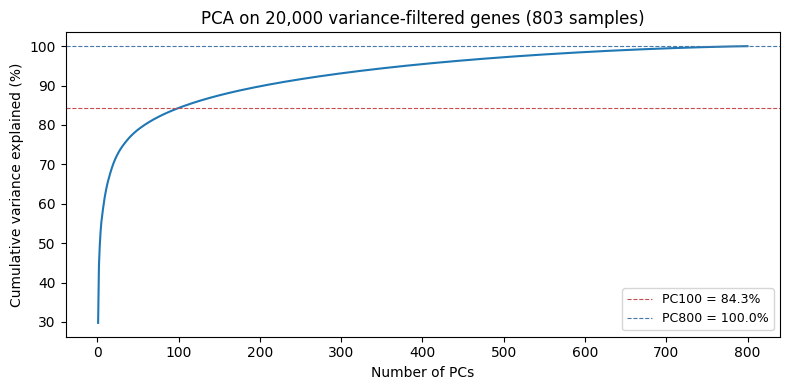

In [2]:
N_PCS = 800  
TOP_K_PCS = 100

# Quick exploratory PCA on variance-filtered genes
scaler_check = StandardScaler()
X_scaled_check = scaler_check.fit_transform(X_wb_var)
n_comp_check = min(N_PCS, X_scaled_check.shape[0] - 1, X_scaled_check.shape[1])
pca_check = PCA(n_components=n_comp_check, random_state=Config.SEED)
pca_check.fit(X_scaled_check)

cum_var = np.cumsum(pca_check.explained_variance_ratio_)
print(f'Top {n_comp_check} PCs explain {cum_var[-1]*100:.1f}% of total variance')
print(f'Top 100 PCs explain {cum_var[99]*100:.1f}%')
print(f'Top 10 PCs explain {cum_var[9]*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_comp_check + 1), cum_var * 100, lw=1.5)
ax.axhline(cum_var[99] * 100, color='#C44E52', ls='--', lw=0.8, label=f'PC100 = {cum_var[99]*100:.1f}%')
ax.axhline(cum_var[-1] * 100, color='#4878A8', ls='--', lw=0.8, label=f'PC{n_comp_check} = {cum_var[-1]*100:.1f}%')
ax.set(xlabel='Number of PCs', ylabel='Cumulative variance explained (%)',
       title=f'PCA on {X_wb_var.shape[1]:,} variance-filtered genes ({X_wb_var.shape[0]} samples)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'pca_cumulative_variance_global.pdf', bbox_inches='tight')
plt.show()

del scaler_check, X_scaled_check, pca_check

## 10.1c — Clinical co-variate Structure on PC1/PC2

Project all 803 whole-blood samples onto PC1-PC10 (same global PCA as §10.1),
merge with the donor clinical co-variate matrix (SEX, AGE, RACE, DTHHRDY, TRISCHD), and
cache to `output/tables/pca_donor_scores_wb20k.csv` for use in Fig 1C. The
inline 1×5 scatter shows where each clinical co-variate structures the top two PCs;
the final paneled layout lives in NB14.

Saved 803 donor-sample rows -> pca_donor_scores_wb20k.csv
Variance explained PC1-PC10: PC1=29.8%, PC2=14.4%, PC3=5.1%, PC4=3.6%, PC5=2.5%, PC6=1.8%, PC7=1.6%, PC8=1.5%, PC9=1.4%, PC10=1.2%


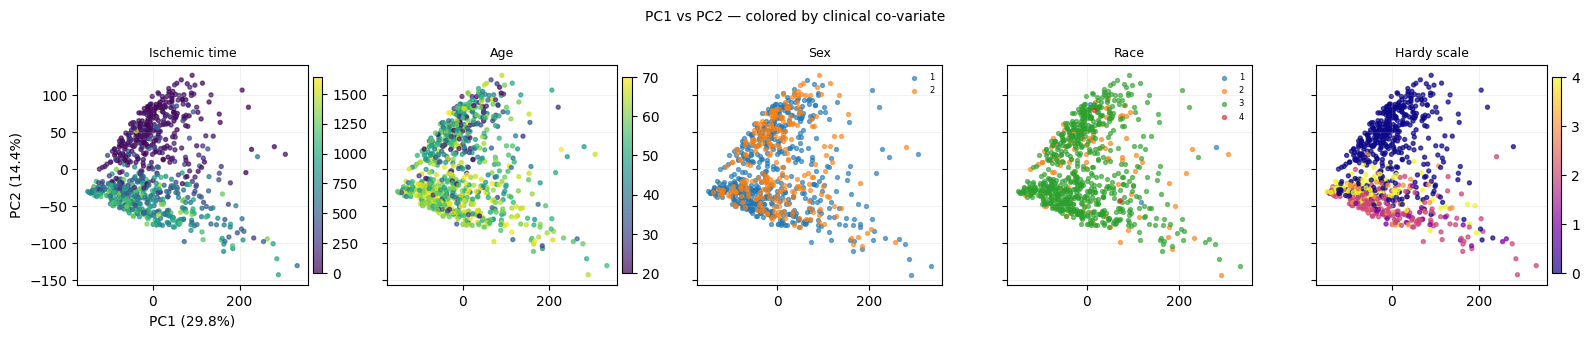

In [3]:
N_PC_FIG = 10

scaler_fig = StandardScaler()
X_sc_fig = scaler_fig.fit_transform(X_wb_var)
n_comp_fig = min(N_PC_FIG, X_sc_fig.shape[0] - 1, X_sc_fig.shape[1])
pca_fig = PCA(n_components=n_comp_fig, random_state=Config.SEED).fit(X_sc_fig)

scores = pca_fig.transform(X_sc_fig)
score_cols = [f"PC{i+1}" for i in range(n_comp_fig)]
donor_scores = pd.DataFrame(scores, columns=score_cols, index=X_wb_var.index)
donor_scores = donor_scores.join(X_conf, how="left")
donor_scores.index.name = "SAMPID"

donor_scores.to_csv(Config.TABLES_DIR / "pca_donor_scores_wb20k.csv")
ve = pca_fig.explained_variance_ratio_
pd.DataFrame({"pc": range(1, n_comp_fig + 1), "var_ratio": ve}).to_csv(
    Config.TABLES_DIR / "pca_explained_variance_top10.csv", index=False)

print(f"Saved {len(donor_scores)} donor-sample rows -> pca_donor_scores_wb20k.csv")
print("Variance explained PC1-PC{}: ".format(n_comp_fig) +
      ", ".join(f"PC{i+1}={ve[i]*100:.1f}%" for i in range(n_comp_fig)))

# Inline 1x5 scatter — final layout in NB14 Fig 1C.
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), sharex=True, sharey=True)
specs = [
    ("TRISCHD", "Ischemic time", "viridis", False),
    ("AGE",     "Age",           "viridis", False),
    ("SEX",     "Sex",           None,      True),
    ("RACE",    "Race",          None,      True),
    ("DTHHRDY", "Hardy scale",   "plasma",  False),
]
for ax, (col, label, cmap, is_cat) in zip(axes, specs):
    if is_cat:
        for v in sorted(donor_scores[col].dropna().unique()):
            sub = donor_scores[donor_scores[col] == v]
            ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.6, label=f"{v:g}")
        ax.legend(fontsize=6, frameon=False, loc="best")
    else:
        sc = ax.scatter(donor_scores["PC1"], donor_scores["PC2"], s=8, alpha=0.7,
                        c=donor_scores[col], cmap=cmap)
        plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(label, fontsize=9)
    ax.grid(True, alpha=0.3, lw=0.4)

axes[0].set_xlabel(f"PC1 ({ve[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({ve[1]*100:.1f}%)")
fig.suptitle("PC1 vs PC2 — colored by clinical co-variate", fontsize=10)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "pca_pc1_pc2_by_confounder.pdf", bbox_inches="tight")
plt.show()

del scaler_fig, X_sc_fig, pca_fig

## 10.1b — Sanity Check: Normalization Properties

Two properties must hold for clean gene-level importance (NB11):

1. **RF Gini importances** sum to 1 across all features — but when we slice PCs only (drop clinical co-variates), the sum < 1. We renormalize so PCs sum to 1.
2. **PCA absolute loadings** — `Σ_j |loading(i,j)| ≠ 1` per PC. We normalize so each PC distributes exactly 100% of its importance across genes.

In [4]:
# Re-fit a quick PCA for the sanity check (same as 10.1)
scaler_sc = StandardScaler()
X_sc = scaler_sc.fit_transform(X_wb_var)
pca_sc = PCA(n_components=min(N_PCS, X_sc.shape[0] - 1), random_state=Config.SEED)
pca_sc.fit(X_sc)

# --- Sanity Check 1: RF Gini importance sums ---
# Train a quick RF on PCs + clinical co-variates for Liver|cirrhosis to demonstrate
y_sc, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_sc = y_sc.notna()
y_sc_clean = y_sc[keep_sc].astype(int)
X_sc_sub = scaler_sc.transform(X_wb_var.loc[keep_sc])
X_pcs_sc = pca_sc.transform(X_sc_sub)

pc_cols_sc = [f'PC{i+1}' for i in range(pca_sc.n_components_)]
X_pcs_df = pd.DataFrame(X_pcs_sc, columns=pc_cols_sc, index=X_wb_var.loc[keep_sc].index)

top_pcs_sc = _auc_feature_selection(X_pcs_df, y_sc_clean, top_k=TOP_K_PCS)
X_conf_sc = X_conf.loc[keep_sc]
# One-shot sanity-check fit (no CV) — impute clinical co-variates with
# the median of this same slice. Real CV runs use train-fold imputation.
X_conf_sc = X_conf_sc.fillna(X_conf_sc.median())
X_sel = pd.concat([X_pcs_df[top_pcs_sc], X_conf_sc], axis=1)

rf_sc = make_rf_model()
rf_sc.fit(X_sel, y_sc_clean)

fi_all = rf_sc.feature_importances_
fi_pcs = fi_all[:len(top_pcs_sc)]
fi_conf = fi_all[len(top_pcs_sc):]

print('=== Sanity Check 1: RF Gini Importance Sums ===')
print(f'  Total (all {len(fi_all)} features):  {fi_all.sum():.6f}  (should be 1.0)')
print(f'  PCs only ({len(fi_pcs)} features):   {fi_pcs.sum():.6f}  (< 1, clinical co-variates absorbed {fi_conf.sum():.4f})')
print(f'  After renorm PCs to 1:     {(fi_pcs / fi_pcs.sum()).sum():.6f}')
print()

# --- Sanity Check 2: Absolute loading norms per PC ---
pc_idx = 0
loadings_pc1 = pca_sc.components_[pc_idx, :]

abs_sum = np.sum(np.abs(loadings_pc1))
abs_norm_sum = np.sum(np.abs(loadings_pc1) / abs_sum)

print('=== Sanity Check 2: Absolute Loading Norms (PC1) ===')
print(f'  Σ |loading|:      {abs_sum:.4f}  (>> 1, not normalized)')
print(f'  After |L|/Σ|L|:   {abs_norm_sum:.6f}  (= 1.0 after normalization)')
del scaler_sc, X_sc, pca_sc, rf_sc

=== Sanity Check 1: RF Gini Importance Sums ===
  Total (all 105 features):  1.000000  (should be 1.0)
  PCs only (100 features):   0.989578  (< 1, clinical co-variates absorbed 0.0104)
  After renorm PCs to 1:     1.000000

=== Sanity Check 2: Absolute Loading Norms (PC1) ===
  Σ |loading|:      126.5693  (>> 1, not normalized)
  After |L|/Σ|L|:   1.000000  (= 1.0 after normalization)


In [5]:
def run_cv_with_pca(X, y, groups, n_pcs=1000, top_k_pcs=100, X_conf_sub=None,
                    cfg=None, tag='', model_factory=None):
    """Leak-free CV: PCA fit inside each fold on training data only.

    If X_conf_sub is provided, clinical co-variates are appended to the selected PCs
    before training the model.  model_factory defaults to make_rf_model;
    pass make_lr_pipeline to run logistic regression on the same PCs.
    """
    cfg = cfg or Config
    if model_factory is None:
        model_factory = make_rf_model
    cv = StratifiedGroupKFold(
        n_splits=cfg.N_SPLITS, shuffle=True, random_state=cfg.SEED
    )

    oof = np.full(len(y), np.nan)
    fold_aucs = []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        # Fit scaler + PCA on training data
        scaler = StandardScaler()
        Xtr_scaled = scaler.fit_transform(Xtr)
        Xte_scaled = scaler.transform(Xte)

        n_comp = min(n_pcs, Xtr_scaled.shape[0] - 1, Xtr_scaled.shape[1])
        pca = PCA(n_components=n_comp, random_state=cfg.SEED)
        Xtr_pcs = pca.fit_transform(Xtr_scaled)
        Xte_pcs = pca.transform(Xte_scaled)

        # Convert to DataFrame for AUC feature selection
        pc_cols = [f'PC{i+1}' for i in range(n_comp)]
        Xtr_pcs = pd.DataFrame(Xtr_pcs, columns=pc_cols, index=Xtr.index)
        Xte_pcs = pd.DataFrame(Xte_pcs, columns=pc_cols, index=Xte.index)

        # AUC-select top PCs on training data
        top_pcs = _auc_feature_selection(Xtr_pcs, ytr, top_k=min(top_k_pcs, n_comp))

        # Subset to selected PCs
        Xtr_sel = Xtr_pcs[top_pcs]
        Xte_sel = Xte_pcs[top_pcs]

        # Append clinical co-variates if provided
        if X_conf_sub is not None:
            Xtr_sel = pd.concat([Xtr_sel, X_conf_sub.iloc[tr]], axis=1)
            Xte_sel = pd.concat([Xte_sel, X_conf_sub.iloc[te]], axis=1)
            # Per-fold median imputation for clinical co-variates (train medians only)
            Xtr_sel, Xte_sel = _impute_train_fold(Xtr_sel, Xte_sel)

        # Train model (RF by default; pass model_factory=make_lr_pipeline for LR)
        model = model_factory()
        model.fit(Xtr_sel, ytr)
        proba = model.predict_proba(Xte_sel)[:, 1]
        oof[te] = proba

        fauc = roc_auc_score(yte, proba)
        fold_aucs.append(fauc)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    print(f'    {tag} Mean AUC = {mean_auc:.3f} +/- {std_auc:.3f}')
    return {'mean_auc': mean_auc, 'std_auc': std_auc, 'fold_aucs': fold_aucs, 'oof': oof, 'y': y}

## 10.2 — Single-Feature AUC: Liver | Cirrhosis

For Liver | cirrhosis, fit PCA on 20K variance-filtered genes → 800 PCs, then
compute the **univariate AUC** of each PC individually against the label.

In [6]:
# Prepare Liver | cirrhosis labels
y_demo, _, n_pos_demo, n_neg_demo = assign_donor_labels(
    df_meta_url, 'Liver', 'cirrhosis', blood_subjid
)
keep_demo = y_demo.notna()
y_demo_clean = y_demo[keep_demo].astype(int)
X_demo = X_wb_var.loc[keep_demo]
print(f'Liver | cirrhosis: {n_pos_demo} positive, {n_neg_demo} negative, {len(y_demo_clean)} total')

# Fit PCA on this subset
scaler_demo = StandardScaler()
X_demo_scaled = scaler_demo.fit_transform(X_demo)
n_comp_demo = min(N_PCS, X_demo_scaled.shape[0] - 1, X_demo_scaled.shape[1])
pca_demo = PCA(n_components=n_comp_demo, random_state=Config.SEED)
X_demo_pcs = pca_demo.fit_transform(X_demo_scaled)

# Univariate AUC: each PC vs label independently
pc_aucs = []
for i in range(n_comp_demo):
    auc_i = roc_auc_score(y_demo_clean, X_demo_pcs[:, i])
    # Flip if below 0.5 (direction doesn't matter for univariate screening)
    pc_aucs.append(max(auc_i, 1 - auc_i))

pc_aucs = np.array(pc_aucs)
top_idx = np.argsort(pc_aucs)[::-1]

print(f'\nTop 10 PCs by univariate AUC:')
for rank, idx in enumerate(top_idx[:10], 1):
    print(f'  {rank}. PC{idx+1}: AUC = {pc_aucs[idx]:.3f}')

print(f'\nPCs with AUC > 0.55: {(pc_aucs > 0.55).sum()} / {n_comp_demo}')
print(f'PCs with AUC > Config.AUC_THRESH ({Config.AUC_THRESH:.2f}): '
      f'{(pc_aucs > Config.AUC_THRESH).sum()} / {n_comp_demo}')

del scaler_demo, X_demo_scaled, pca_demo, X_demo_pcs

Liver | cirrhosis: 49 positive, 386 negative, 435 total



Top 10 PCs by univariate AUC:
  1. PC1: AUC = 0.711
  2. PC13: AUC = 0.695
  3. PC434: AUC = 0.668
  4. PC7: AUC = 0.666
  5. PC4: AUC = 0.659
  6. PC65: AUC = 0.641
  7. PC10: AUC = 0.640
  8. PC151: AUC = 0.631
  9. PC48: AUC = 0.628
  10. PC54: AUC = 0.624

PCs with AUC > 0.55: 138 / 434
PCs with AUC > Config.AUC_THRESH (0.60): 26 / 434


## 10.2b — CV-Folded Univariate PC AUC for Liver | Cirrhosis

Compute the univariate AUC of each PC against the cirrhosis label across 5 CV
folds (StratifiedGroupKFold, same splits used elsewhere) and report mean ± SD
per PC.  PCA is fit once globally on the Liver | cirrhosis subset so PC
identity is stable across folds — this *does* leak test-fold info into PC
directions, which is acceptable here because the panel is descriptive (showing
"which PCs discriminate single-handedly?") and predictive numbers in §10.3+ use
the leak-free per-fold PCA.

Saves to `output/tables/liver_cirrhosis_pc_univariate_auc.csv` for use in
Fig 2 panel A.

In [7]:
# CV-folded univariate AUC for each PC.  PCA is fit once globally on the
# Liver|cirrhosis subset (so PC identity is stable across folds — a global
# fit leaks test-fold info into the PC directions, but this section is
# descriptive, not predictive).  Predictive PC numbers in 10.3+ use the
# leak-free per-fold PCA.
N_PCS_UV = 800

y_uv, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_uv = y_uv.notna()
y_uv_clean = y_uv[keep_uv].astype(int)
g_uv = blood_subjid[keep_uv].astype(str)
X_uv = X_wb_var.loc[keep_uv]

scaler_uv = StandardScaler()
X_uv_scaled = scaler_uv.fit_transform(X_uv)
n_comp_uv = min(N_PCS_UV, X_uv_scaled.shape[0] - 1, X_uv_scaled.shape[1])
pca_uv = PCA(n_components=n_comp_uv, random_state=Config.SEED)
X_uv_pcs = pca_uv.fit_transform(X_uv_scaled)

cv_uv = StratifiedGroupKFold(
    n_splits=Config.N_SPLITS, shuffle=True, random_state=Config.SEED)
fold_aucs_uv = np.zeros((Config.N_SPLITS, n_comp_uv))
for fold, (tr, te) in enumerate(cv_uv.split(X_uv_pcs, y_uv_clean, groups=g_uv)):
    y_te = y_uv_clean.iloc[te].values
    for pc_i in range(n_comp_uv):
        a = roc_auc_score(y_te, X_uv_pcs[te, pc_i])
        # Direction-agnostic — a PC's sign is arbitrary
        fold_aucs_uv[fold, pc_i] = max(a, 1 - a)

mean_uv = fold_aucs_uv.mean(axis=0)
std_uv  = fold_aucs_uv.std(axis=0)

uv_df = (pd.DataFrame({'pc': np.arange(1, n_comp_uv + 1),
                       'mean_auc': mean_uv, 'std_auc': std_uv})
           .sort_values('mean_auc', ascending=False)
           .reset_index(drop=True))
uv_df.to_csv(Config.TABLES_DIR / 'liver_cirrhosis_pc_univariate_auc.csv',
             index=False)
print(f'Saved {len(uv_df)} PCs -> liver_cirrhosis_pc_univariate_auc.csv')
print('\nTop 10 PCs by CV-mean univariate AUC:')
display(uv_df.head(10))

del scaler_uv, X_uv_scaled, pca_uv, X_uv_pcs, fold_aucs_uv

Saved 434 PCs -> liver_cirrhosis_pc_univariate_auc.csv

Top 10 PCs by CV-mean univariate AUC:


,pc,mean_auc,std_auc
0,1,0.710470,0.098115
1,13,0.698452,0.107128
2,434,0.669789,0.079541
3,374,0.668013,0.064730
4,305,0.660423,0.083990
5,7,0.659978,0.103412
6,388,0.652471,0.051139
7,4,0.651614,0.065211
8,10,0.646231,0.101262
9,65,0.644687,0.036841


## 10.2c — PC-RF Gini Importance for Liver | Cirrhosis (Figure 3 panel A)

We then train a PC-RF model on the same Liver | cirrhosis subset and extract
per-PC Gini importance under five-fold donor-grouped CV. PCA is fit once
globally (mirroring §10.2b — descriptive, not predictive), so the same 100 PCs
appear in every fold and can be ranked by mean Gini ± SD across folds. The 100
PCs entering the RF are those with the highest globally-computed univariate
mean CV AUC (loaded from §10.2b).

Output: `liver_cirrhosis_pc_rf_gini.csv` — columns: `pc`, `mean_gini`, `std_gini`.

In [8]:
# Re-prep Liver | cirrhosis labels and data (variables from §10.2b were del'd)
y_g, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_g = y_g.notna()
y_g = y_g[keep_g].astype(int)
g_g = blood_subjid[keep_g].astype(str)
X_g = X_wb_var.loc[keep_g]

# Global PCA (descriptive — same approach as §10.2b)
N_PCS_GINI = 800
scaler_g = StandardScaler()
X_g_scaled = scaler_g.fit_transform(X_g)
n_comp_g = min(N_PCS_GINI, X_g_scaled.shape[0] - 1, X_g_scaled.shape[1])
pca_g = PCA(n_components=n_comp_g, random_state=Config.SEED)
X_g_pcs = pca_g.fit_transform(X_g_scaled)

# Pick top 100 PCs by globally-computed univariate CV AUC (from §10.2b)
uv = pd.read_csv(Config.TABLES_DIR / 'liver_cirrhosis_pc_univariate_auc.csv')
top100_pcs = uv.head(100)['pc'].astype(int).values  # 1-indexed PC numbers
top100_idx = top100_pcs - 1                          # 0-indexed
X_g_pcs100 = X_g_pcs[:, top100_idx]

# 5-fold donor-grouped CV: train RF, extract Gini per fold
cv_g = StratifiedGroupKFold(
    n_splits=Config.N_SPLITS, shuffle=True, random_state=Config.SEED)
fold_gini = np.zeros((Config.N_SPLITS, len(top100_pcs)))
for fold, (tr, te) in enumerate(cv_g.split(X_g_pcs100, y_g, groups=g_g)):
    rf = make_rf_model()
    rf.fit(X_g_pcs100[tr], y_g.iloc[tr])
    fold_gini[fold] = rf.feature_importances_

mean_gini = fold_gini.mean(axis=0)
std_gini  = fold_gini.std(axis=0)

gini_df = (pd.DataFrame({'pc': top100_pcs,
                         'mean_gini': mean_gini,
                         'std_gini':  std_gini})
             .sort_values('mean_gini', ascending=False)
             .reset_index(drop=True))
gini_df.to_csv(Config.TABLES_DIR / 'liver_cirrhosis_pc_rf_gini.csv', index=False)
print(f'Saved {len(gini_df)} PCs -> liver_cirrhosis_pc_rf_gini.csv')
print('\nTop 10 PCs by mean Gini importance:')
display(gini_df.head(10))

del scaler_g, X_g_scaled, pca_g, X_g_pcs, X_g_pcs100, fold_gini

Saved 100 PCs -> liver_cirrhosis_pc_rf_gini.csv

Top 10 PCs by mean Gini importance:


,pc,mean_gini,std_gini
0,13,0.038268,0.014682
1,434,0.035294,0.008705
2,51,0.031676,0.009541
3,7,0.026505,0.011787
4,1,0.023628,0.004386
5,48,0.020651,0.005566
6,10,0.020007,0.006689
7,28,0.019494,0.007867
8,54,0.018217,0.007119
9,20,0.017920,0.006373


## 10.3 — Run All Pairs

Leak-free PC-based CV on all tissue × pathology pairs (20K variance-filtered genes).

In [9]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f'{len(pairs_df)} tissue x category pairs\n')

pc_results = []
for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]  # variance-filtered 20K genes

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')
    res = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS, tag=tag)
    pc_results.append({'tissue': tissue, 'category': cat, 'auc_pc': res['mean_auc'],
                       'std_pc': res['std_auc']})

pc_auc = pd.DataFrame(pc_results)
print(f'Completed {len(pc_auc)} models')
print(f'Mean PC AUC across all models: {pc_auc["auc_pc"].mean():.3f}')

59 tissue x category pairs

[ 1/59] Adipose - Subcutaneous | fibrosis  (n_pos=228, n_neg=33)


    Adipose - Subcutaneous | fibrosis Mean AUC = 0.493 +/- 0.114
[ 2/59] Adipose - Visceral (Omentum) | fibrosis  (n_pos=118, n_neg=55)


    Adipose - Visceral (Omentum) | fibrosis Mean AUC = 0.530 +/- 0.059
[ 3/59] Artery - Aorta | atherosis  (n_pos=195, n_neg=276)


    Artery - Aorta | atherosis Mean AUC = 0.465 +/- 0.070
[ 4/59] Artery - Aorta | plaque  (n_pos=92, n_neg=379)


    Artery - Aorta | plaque Mean AUC = 0.549 +/- 0.088
[ 5/59] Artery - Aorta | atherosclerosis  (n_pos=88, n_neg=383)


...

    Testis | spermatogenesis Mean AUC = 0.658 +/- 0.038
[56/59] Thyroid | fibrosis  (n_pos=124, n_neg=335)


    Thyroid | fibrosis Mean AUC = 0.516 +/- 0.052
[57/59] Thyroid | nodularity  (n_pos=103, n_neg=356)


    Thyroid | nodularity Mean AUC = 0.487 +/- 0.085
[58/59] Thyroid | hashimoto  (n_pos=56, n_neg=403)


    Thyroid | hashimoto Mean AUC = 0.509 +/- 0.120
[59/59] Thyroid | goiter  (n_pos=50, n_neg=409)


    Thyroid | goiter Mean AUC = 0.507 +/- 0.117
Completed 59 models
Mean PC AUC across all models: 0.548


## 10.4 — Liver | Cirrhosis in Context

Where does the Liver | cirrhosis pair rank against the rest of the screen?

In [10]:
pc_auc_sorted = pc_auc.copy()
pc_auc_sorted['label'] = pc_auc_sorted['tissue'] + ' | ' + pc_auc_sorted['category']
pc_auc_sorted = pc_auc_sorted.sort_values('auc_pc', ascending=False).reset_index(drop=True)

rank = pc_auc_sorted[pc_auc_sorted['label'] == 'Liver | cirrhosis'].index[0] + 1
auc_val = pc_auc_sorted.loc[pc_auc_sorted['label'] == 'Liver | cirrhosis', 'auc_pc'].values[0]
print(f'Liver | cirrhosis PC AUC: {auc_val:.3f}  (rank {rank}/{len(pc_auc_sorted)})')

Liver | cirrhosis PC AUC: 0.783  (rank 2/59)


## 10.5 — PC AUC Bar Chart

Horizontal bar chart of PC-based AUC across the full screened set of tissue × pathology pairs, sorted by AUC.

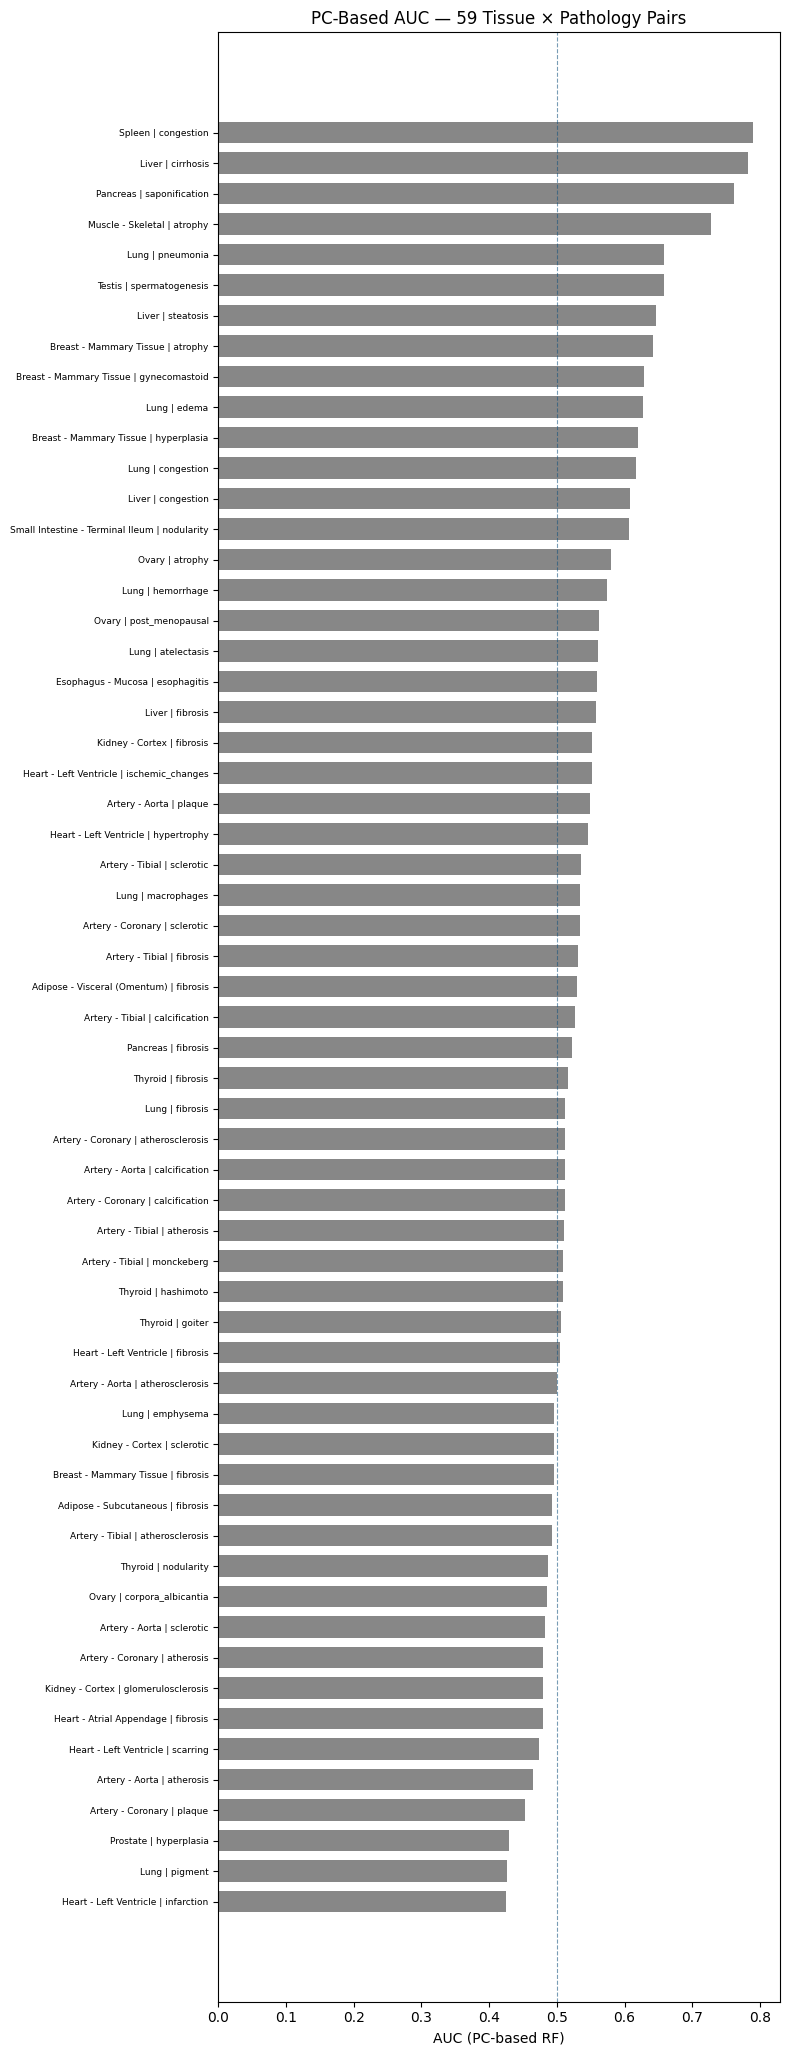

In [11]:
plot_df = pc_auc.copy()
plot_df['label'] = plot_df['tissue'] + ' | ' + plot_df['category']
plot_df = plot_df.sort_values('auc_pc', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(10, len(plot_df) * 0.35)))
ax.barh(range(len(plot_df)), plot_df['auc_pc'], color='#555555', height=0.7, alpha=0.7)
ax.axvline(0.5, ls='--', lw=0.8, color="#13527E92")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=6.5)
ax.set_xlabel('AUC (PC-based RF)')
ax.set_title(f'PC-Based AUC — {len(plot_df)} Tissue × Pathology Pairs')
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'pc_auc_bar.pdf', bbox_inches='tight')
plt.show()

## 10.6 — PC + Clinical co-variates (All Pairs)

Same leak-free CV as 10.3, but clinical co-variates (SEX, AGE, RACE, DTHHRDY, TRISCHD) are
appended to the selected PCs before training the RF.

In [12]:
pc_conf_results = []
for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]  # variance-filtered 20K genes
    X_conf_sub = X_conf.loc[keep]

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')
    res = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
                          X_conf_sub=X_conf_sub, tag=tag)
    pc_conf_results.append({'tissue': tissue, 'category': cat,
                            'auc_pc_conf': res['mean_auc'], 'std_pc_conf': res['std_auc']})

pc_conf_auc = pd.DataFrame(pc_conf_results)
print(f'\nCompleted {len(pc_conf_auc)} PC + co-variates models')
print(f'Mean PC + co-variates AUC: {pc_conf_auc["auc_pc_conf"].mean():.3f}')

[ 1/59] Adipose - Subcutaneous | fibrosis  (n_pos=228, n_neg=33)


    Adipose - Subcutaneous | fibrosis Mean AUC = 0.501 +/- 0.110
[ 2/59] Adipose - Visceral (Omentum) | fibrosis  (n_pos=118, n_neg=55)


    Adipose - Visceral (Omentum) | fibrosis Mean AUC = 0.487 +/- 0.056
[ 3/59] Artery - Aorta | atherosis  (n_pos=195, n_neg=276)


    Artery - Aorta | atherosis Mean AUC = 0.464 +/- 0.072
[ 4/59] Artery - Aorta | plaque  (n_pos=92, n_neg=379)


    Artery - Aorta | plaque Mean AUC = 0.536 +/- 0.067
[ 5/59] Artery - Aorta | atherosclerosis  (n_pos=88, n_neg=383)


...

    Testis | spermatogenesis Mean AUC = 0.693 +/- 0.053
[56/59] Thyroid | fibrosis  (n_pos=124, n_neg=335)


    Thyroid | fibrosis Mean AUC = 0.516 +/- 0.057
[57/59] Thyroid | nodularity  (n_pos=103, n_neg=356)


    Thyroid | nodularity Mean AUC = 0.498 +/- 0.058
[58/59] Thyroid | hashimoto  (n_pos=56, n_neg=403)


    Thyroid | hashimoto Mean AUC = 0.474 +/- 0.110
[59/59] Thyroid | goiter  (n_pos=50, n_neg=409)


    Thyroid | goiter Mean AUC = 0.513 +/- 0.105

Completed 59 PC + co-variates models
Mean PC + co-variates AUC: 0.567


## 10.7 — Comparison: PC + co-variates vs Co-variates only

Side-by-side bar chart showing PC + co-variates AUC vs Co-variates only AUC (from NB09).
This shows how much the PCs add on top of demographics.

Mean Co-variates only AUC: 0.567
Mean PC + co-variates AUC:   0.567


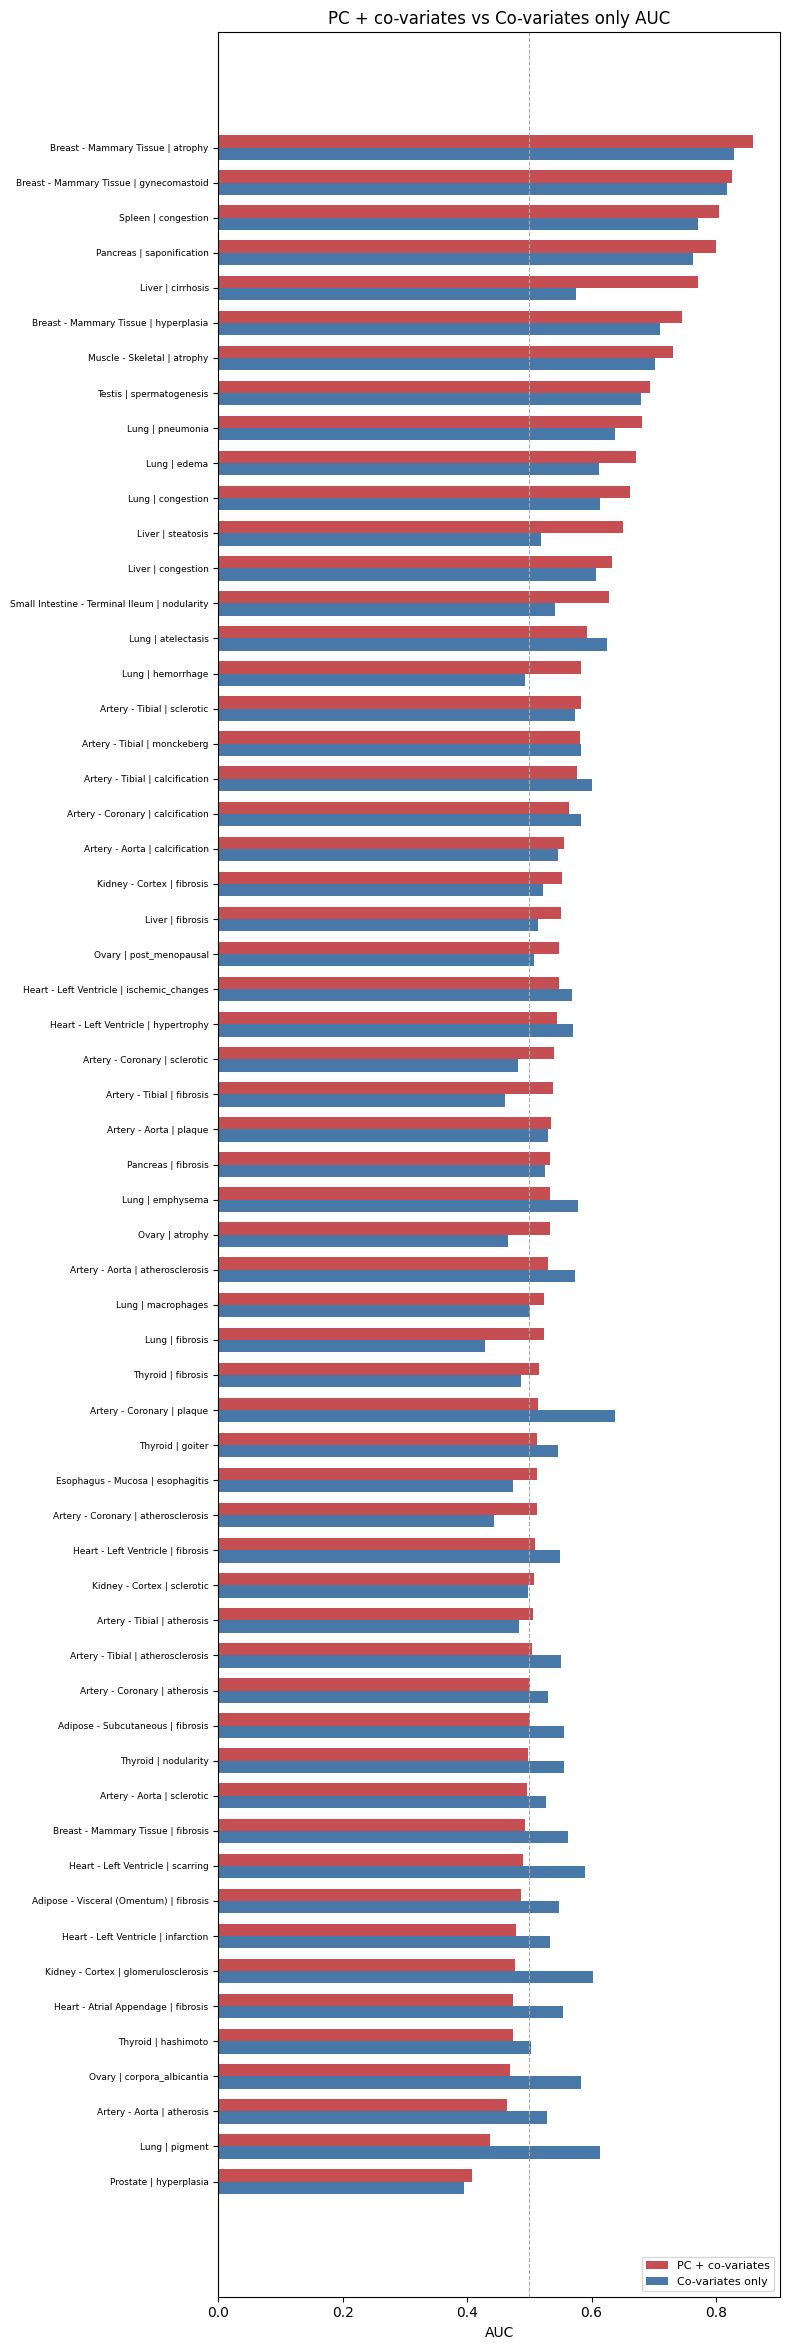

In [13]:
# Merge PC + co-variates with co-variates only AUC from three_way (NB09)
comp = pc_conf_auc.merge(
    three_way[['tissue', 'category', 'auc_conf']],
    on=['tissue', 'category']
)
comp = comp.merge(pc_auc, on=['tissue', 'category'])
comp['delta_pc'] = comp['auc_pc_conf'] - comp['auc_conf']

print(f'Mean Co-variates only AUC: {comp["auc_conf"].mean():.3f}')
print(f'Mean PC + co-variates AUC:   {comp["auc_pc_conf"].mean():.3f}')

_ = plot_paired_auc_bar(
    comp, auc_col_a='auc_pc_conf', auc_col_b='auc_conf',
    label_a='PC + co-variates', label_b='Co-variates only',
    title='PC + co-variates vs Co-variates only AUC',
    save_path=Config.FIGURES_DIR / 'pc_conf_vs_conf_bar.pdf'
)

## 10.8 — ΔAUC: PC Gain Over Clinical co-variates

**Δ = AUC(PC + co-variates) − AUC(Co-variates only)**

How much do PCs add beyond demographics alone? Uses co-variates only AUC from NB09.

Mean Δ (PC gain over conf): 0.0002


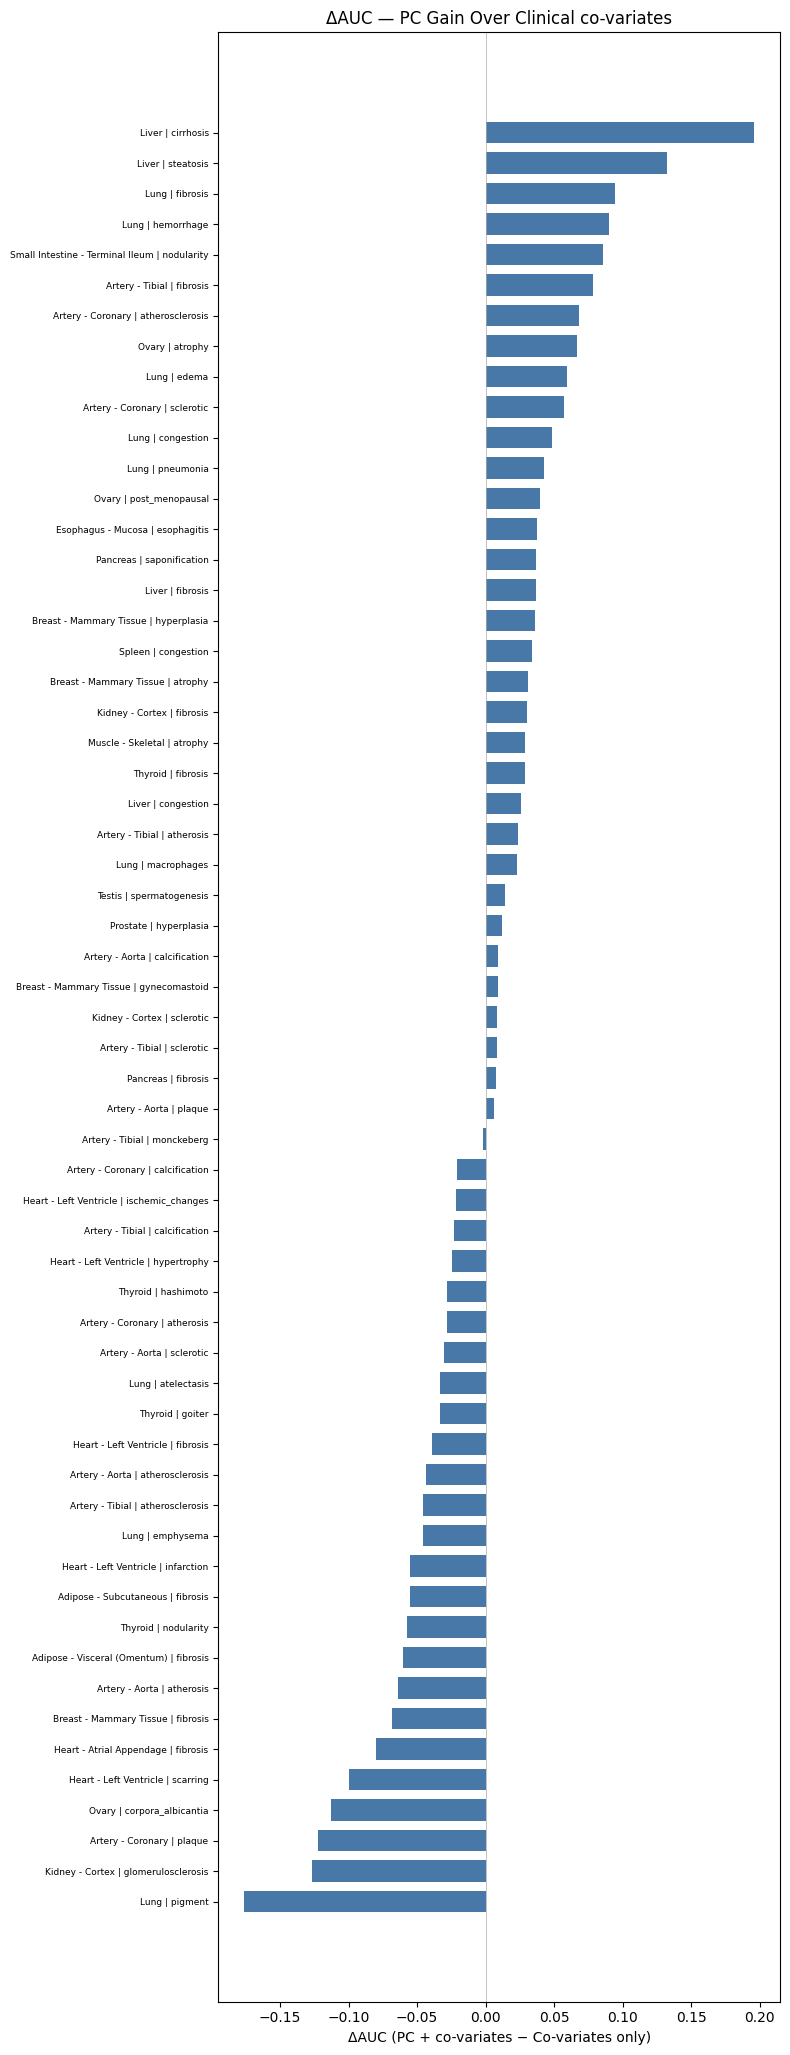

In [14]:
delta_df = comp[['tissue', 'category', 'auc_pc', 'auc_pc_conf', 'auc_conf', 'delta_pc']].copy()

print(f'Mean Δ (PC gain over conf): {delta_df["delta_pc"].mean():.4f}')

_ = plot_delta_bar(
    delta_df, delta_col='delta_pc',
    title='ΔAUC — PC Gain Over Clinical co-variates',
    xlabel='ΔAUC (PC + co-variates − Co-variates only)',
    save_path=Config.FIGURES_DIR / 'delta_auc_pc_over_conf.pdf'
)

## 10.9 — Export

In [15]:
# Save with delta column
export_df = comp[['tissue', 'category', 'auc_pc', 'std_pc', 'auc_pc_conf', 'std_pc_conf', 'auc_conf', 'delta_pc']].copy()
export_df['label'] = export_df['tissue'] + ' | ' + export_df['category']
export_df = export_df.sort_values('delta_pc', ascending=False).reset_index(drop=True)
export_df.to_csv(Config.TABLES_DIR / 'pc_auc_results.csv', index=False)
print(f'Saved {len(export_df)} rows → output/tables/pc_auc_results.csv')
display(export_df)

Saved 59 rows → output/tables/pc_auc_results.csv


,tissue,category,auc_pc,std_pc,auc_pc_conf,std_pc_conf,auc_conf,delta_pc,label
0,Liver,cirrhosis,0.782928,0.033880,0.771281,0.041681,0.574958,0.196323,Liver | cirrhosis
1,Liver,steatosis,0.646512,0.010974,0.650634,0.020254,0.518129,0.132505,Liver | steatosis
2,Lung,fibrosis,0.512057,0.054623,0.523182,0.057634,0.428681,0.094501,Lung | fibrosis
3,Lung,hemorrhage,0.573618,0.046536,0.583162,0.032748,0.493336,0.089827,Lung | hemorrhage
4,Small Intestine - Terminal Ileum,nodularity,0.607060,0.043865,0.627552,0.040522,0.541722,0.085829,Small Intestine - Terminal Ileum | nodularity
5,Artery - Tibial,fibrosis,0.531885,0.035672,0.538384,0.029644,0.460118,0.078266,Artery - Tibial | fibrosis
6,Artery - Coronary,atherosclerosis,0.512049,0.056322,0.511771,0.069343,0.443340,0.068431,Artery - Coronary | atherosclerosis
7,Ovary,atrophy,0.580036,0.080374,0.532804,0.094872,0.465742,0.067062,Ovary | atrophy
8,Lung,edema,0.626623,0.065266,0.670916,0.080132,0.611559,0.059357,Lung | edema
9,Artery - Coronary,sclerotic,0.533645,0.044992,0.539739,0.029440,0.482578,0.057161,Artery - Coronary | sclerotic


In [16]:
n_qual = ((comp['auc_pc_conf'] >= Config.AUC_THRESH) & (comp['delta_pc'] >= Config.DELTA_THRESH)).sum()
print(f"Qualifying models (AUC_THRESH={Config.AUC_THRESH:.2f}, DELTA_THRESH={Config.DELTA_THRESH:.2f}): {n_qual} / {len(comp)}")


Qualifying models (AUC_THRESH=0.60, DELTA_THRESH=0.05): 4 / 59


## 10.10 — PC-LR (Logistic Regression on PCs)

Run logistic regression on the same PC features used by the PC-RF runs in
§10.3 / §10.6 — for both expression-only (PC-LR) and expression+clinical co-variates
(PC-LR + conf).  Re-uses `run_cv_with_pca` with `model_factory=make_lr_pipeline`.

Saves to `output/tables/pc_lr_results.csv` with columns
`tissue, category, auc_pc_lr, std_pc_lr, auc_pc_lr_conf, std_pc_lr_conf`
for use in Fig 2 panel B.

In [17]:
pc_lr_results = []
pc_lr_conf_results = []

for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]
    X_conf_sub = X_conf.loc[keep]

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')

    res_lr = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
                             tag=f'{tag} [LR]', model_factory=make_lr_pipeline)
    pc_lr_results.append({'tissue': tissue, 'category': cat,
                          'auc_pc_lr': res_lr['mean_auc'],
                          'std_pc_lr': res_lr['std_auc']})

    res_lr_conf = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
                                  X_conf_sub=X_conf_sub,
                                  tag=f'{tag} [LR+conf]',
                                  model_factory=make_lr_pipeline)
    pc_lr_conf_results.append({'tissue': tissue, 'category': cat,
                               'auc_pc_lr_conf': res_lr_conf['mean_auc'],
                               'std_pc_lr_conf': res_lr_conf['std_auc']})

pc_lr_df = (pd.DataFrame(pc_lr_results)
              .merge(pd.DataFrame(pc_lr_conf_results), on=['tissue', 'category']))
pc_lr_df.to_csv(Config.TABLES_DIR / 'pc_lr_results.csv', index=False)
print(f'\nCompleted {len(pc_lr_df)} PC-LR + PC-LR+conf models')
print(f'Mean PC-LR AUC:        {pc_lr_df["auc_pc_lr"].mean():.3f}')
print(f'Mean PC-LR + conf AUC: {pc_lr_df["auc_pc_lr_conf"].mean():.3f}')
print(f'Saved -> output/tables/pc_lr_results.csv')

[ 1/59] Adipose - Subcutaneous | fibrosis  (n_pos=228, n_neg=33)


    Adipose - Subcutaneous | fibrosis [LR] Mean AUC = 0.525 +/- 0.134


    Adipose - Subcutaneous | fibrosis [LR+conf] Mean AUC = 0.546 +/- 0.152
[ 2/59] Adipose - Visceral (Omentum) | fibrosis  (n_pos=118, n_neg=55)


    Adipose - Visceral (Omentum) | fibrosis [LR] Mean AUC = 0.592 +/- 0.065


    Adipose - Visceral (Omentum) | fibrosis [LR+conf] Mean AUC = 0.581 +/- 0.050
[ 3/59] Artery - Aorta | atherosis  (n_pos=195, n_neg=276)


...

    Thyroid | nodularity [LR+conf] Mean AUC = 0.465 +/- 0.068
[58/59] Thyroid | hashimoto  (n_pos=56, n_neg=403)


    Thyroid | hashimoto [LR] Mean AUC = 0.453 +/- 0.081


    Thyroid | hashimoto [LR+conf] Mean AUC = 0.453 +/- 0.074
[59/59] Thyroid | goiter  (n_pos=50, n_neg=409)


    Thyroid | goiter [LR] Mean AUC = 0.482 +/- 0.088


    Thyroid | goiter [LR+conf] Mean AUC = 0.504 +/- 0.100

Completed 59 PC-LR + PC-LR+conf models
Mean PC-LR AUC:        0.556
Mean PC-LR + conf AUC: 0.572
Saved -> output/tables/pc_lr_results.csv


## 10.11 — Liver six-model summaries (for NB16 Fig 2B)


In [18]:
# ── Build six-model AUC summaries for the two qualifying Liver pairs ──
# Combines LR raw (NB05), RF raw (NB07), PC-LR expr / expr+co-vars (this NB),
# PC-RF expr / expr+co-vars (this NB) into a single per-pair table that NB16
# and NB17 consume for the Figure 2B / Liver six-model panel.
import pandas as pd

lr_raw_df = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")
rf_raw_df = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")

def _row(df, tissue, cat):
    sub = df[(df["tissue"] == tissue) & (df["category"] == cat)]
    return sub.iloc[0] if len(sub) else None

def build_six_model(tissue, cat):
    lr = _row(lr_raw_df, tissue, cat)
    rf = _row(rf_raw_df, tissue, cat)
    pcr = _row(comp, tissue, cat)        # has auc_pc, std_pc, auc_pc_conf, std_pc_conf
    pcl = _row(pc_lr_df, tissue, cat)    # has auc_pc_lr, std_pc_lr, auc_pc_lr_conf, std_pc_lr_conf
    if any(x is None for x in [lr, rf, pcr, pcl]):
        return None
    return pd.DataFrame([
        {"model": "LR raw",               "mean_auc": lr["mean_auc"],       "std_auc": lr["std_auc"]},
        {"model": "RF raw",               "mean_auc": rf["mean_auc"],       "std_auc": rf["std_auc"]},
        {"model": "PC-LR (expr)",         "mean_auc": pcl["auc_pc_lr"],     "std_auc": pcl["std_pc_lr"]},
        {"model": "PC-RF (expr)",         "mean_auc": pcr["auc_pc"],        "std_auc": pcr["std_pc"]},
        {"model": "PC-LR (expr+co-vars)", "mean_auc": pcl["auc_pc_lr_conf"],"std_auc": pcl["std_pc_lr_conf"]},
        {"model": "PC-RF (expr+co-vars)", "mean_auc": pcr["auc_pc_conf"],   "std_auc": pcr["std_pc_conf"]},
    ])

for tissue, cat, name in [("Liver", "cirrhosis", "liver_cirrhosis"),
                          ("Liver", "steatosis", "liver_steatosis")]:
    six = build_six_model(tissue, cat)
    if six is None:
        print(f"  skip {tissue} | {cat} (missing source row)")
        continue
    out = Config.TABLES_DIR / f"{name}_six_model_auc.csv"
    six.to_csv(out, index=False)
    print(f"Saved {out.name}")
    display(six)


Saved liver_cirrhosis_six_model_auc.csv


,model,mean_auc,std_auc
0,LR raw,0.820400,0.070070
1,RF raw,0.794853,0.082792
2,PC-LR (expr),0.817232,0.051233
3,PC-RF (expr),0.782928,0.033880
4,PC-LR (expr+co-vars),0.810143,0.040120
5,PC-RF (expr+co-vars),0.771281,0.041681


Saved liver_steatosis_six_model_auc.csv


,model,mean_auc,std_auc
0,LR raw,0.576744,0.072088
1,RF raw,0.627114,0.030509
2,PC-LR (expr),0.625793,0.026480
3,PC-RF (expr),0.646512,0.010974
4,PC-LR (expr+co-vars),0.634672,0.028195
5,PC-RF (expr+co-vars),0.650634,0.020254
